In [1]:
import os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')  # run from project root for data/, outputs/
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Load clean dataset from csv

In [2]:
df_lost = pd.read_csv("data/df_lost_final.csv")
df_trapped = pd.read_csv("data/df_trapped_final.csv")

df_lost = df_lost[df_lost["r2"] > 0.0]
df_trapped = df_trapped[df_trapped["r2"] > 0.0]

df_lost

,U2,RF_set_dBm,RF_set_mW,RF_meas_dBm,act_RF_mW,n_peaks,r2,aicc,c0,split_x_MHz,...,sigma5,amp6,mu6,sigma6,amp7,mu7,sigma7,amp8,mu8,sigma8
0,-0.35,-0.5,0.891251,9.925784,9.830563,6,0.992405,-3128.695437,0.015153,71.038937,...,1.074748,0.018299,122.674342,0.500000,NaN,NaN,NaN,NaN,NaN,NaN
1,-0.35,0.0,1.000000,10.330446,10.790574,7,0.994047,-3079.085158,0.022659,72.643508,...,0.905387,0.010039,115.979095,0.500000,0.019230,129.533757,0.697587,NaN,NaN,NaN
2,-0.35,0.2,1.047129,10.450421,11.092823,7,0.992710,-2999.286957,0.018178,125.102762,...,0.569473,0.020792,117.501795,0.500000,0.015207,132.703728,0.735163,NaN,NaN,NaN
3,-0.35,0.4,1.096478,10.560865,11.378540,7,0.988856,-2889.147110,0.015499,60.038402,...,0.862252,0.036982,119.589123,0.525846,0.009434,134.615148,0.603285,NaN,NaN,NaN
4,-0.35,0.6,1.148154,10.694586,11.734339,6,0.989071,-2992.472265,0.015043,76.411396,...,0.504210,0.011628,121.054983,0.500000,NaN,NaN,NaN,NaN,NaN,NaN
5,-0.35,0.8,1.202264,10.792148,12.000926,7,0.987428,-3007.430498,0.011864,82.121920,...,0.500000,0.013679,123.678927,1.824887,0.009395,136.710881,0.578939,NaN,NaN,NaN
6,-0.35,1.0,1.258925,10.989132,12.557790,7,0.991394,-3106.159157,0.015741,96.611782,...,0.737471,0.019936,121.008505,0.667641,0.013944,124.600902,1.008262,NaN,NaN,NaN
7,-0.35,1.2,1.318257,11.085116,12.838421,8,0.771610,-2377.579400,0.006551,85.544452,...,0.645910,0.010194,119.406687,1.191654,0.015109,122.315049,0.627933,0.010978,128.589089,0.89473
8,-0.35,1.4,1.380384,11.196874,13.173082,6,0.978675,-2888.606019,0.027830,93.291385,...,1.507702,0.010451,129.980842,1.275266,NaN,NaN,NaN,NaN,NaN,NaN
9,-0.35,1.6,1.445440,11.267139,13.387943,5,0.982420,-2929.138675,0.014335,85.653799,...,1.079417,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
def get_all_peaks(df):
    # auto detect maximum number of peaks
    amp_cols = [c for c in df.columns if c.startswith("amp") and c[3:].isdigit()]
    max_peak = max(int(c[3:]) for c in amp_cols) if amp_cols else 8
    
    all_peaks = []
    for i, row in df.iterrows():
        peaks = {}
        peaks["RF_set_dBm"] = row["RF_set_dBm"]
        peaks["act_RF_mW"] = row["act_RF_mW"]
        peaks["peaks"] = []
        for i in range(1, max_peak + 1):
            amp = row[f"amp{i}"]
            mu = row[f"mu{i}"]
            sigma = row[f"sigma{i}"]
            if pd.notna(amp) and pd.notna(mu) and pd.notna(sigma):
                peaks["peaks"].append({"amp": amp, "mu": mu, "sigma": sigma})
        all_peaks.append(peaks)
    return all_peaks

all_peaks_lost = get_all_peaks(df_lost)
all_peaks_trapped = get_all_peaks(df_trapped)

all_peaks_lost

[{'RF_set_dBm': -0.5,
  'act_RF_mW': 9.830563459564187,
  'peaks': [{'amp': 0.0457804367285503,
    'mu': 44.47412647914517,
    'sigma': 1.55411200270826},
   {'amp': 0.0523773671977077,
    'mu': 50.359121156532,
    'sigma': 0.6057980566243565},
   {'amp': 0.0184756590926851,
    'mu': 61.07822281625962,
    'sigma': 0.5000000000000001},
   {'amp': 0.0439121324440958,
    'mu': 96.2255522424855,
    'sigma': 0.5000000000000001},
   {'amp': 0.0142171954175614,
    'mu': 101.25239281171376,
    'sigma': 1.074748269880106},
   {'amp': 0.0182990957595592,
    'mu': 122.6743421069112,
    'sigma': 0.5000000000000001}]},
 {'RF_set_dBm': 0.0,
  'act_RF_mW': 10.790574302568103,
  'peaks': [{'amp': 0.0425737173485149,
    'mu': 46.935401463239096,
    'sigma': 2.651112866346369},
   {'amp': 0.0538423226257174,
    'mu': 51.39234558547062,
    'sigma': 0.9622113695374644},
   {'amp': 0.0191287242280105,
    'mu': 64.53818751895658,
    'sigma': 0.5123338127479444},
   {'amp': 0.03865614942087

# Categorize peak families

### 1. Preparation: Define family seeds, prepare all points

In [4]:
### Define family seeds (lost)
seed_family_lost = [[], []]
seed_family_lost[0].append([all_peaks_lost[-1]["act_RF_mW"], all_peaks_lost[-1]["peaks"][0]["mu"], all_peaks_lost[-1]["peaks"][0]["sigma"]])
seed_family_lost[0].append([all_peaks_lost[-1]["act_RF_mW"], all_peaks_lost[-1]["peaks"][3]["mu"], all_peaks_lost[-1]["peaks"][3]["sigma"]])
seed_family_lost[0].append([all_peaks_lost[-1]["act_RF_mW"], all_peaks_lost[-1]["peaks"][4]["mu"], all_peaks_lost[-1]["peaks"][4]["sigma"]])
seed_family_lost[0].append([all_peaks_lost[-1]["act_RF_mW"], all_peaks_lost[-1]["peaks"][6]["mu"], all_peaks_lost[-1]["peaks"][6]["sigma"]])
seed_family_lost[0].append([all_peaks_lost[-5]["act_RF_mW"], all_peaks_lost[-5]["peaks"][4]["mu"], all_peaks_lost[-5]["peaks"][4]["sigma"]])
seed_family_lost[0].append([all_peaks_lost[-12]["act_RF_mW"], all_peaks_lost[-12]["peaks"][5]["mu"], all_peaks_lost[-12]["peaks"][5]["sigma"]])
seed_family_lost[0].append([all_peaks_lost[-15]["act_RF_mW"], all_peaks_lost[-15]["peaks"][6]["mu"], all_peaks_lost[-15]["peaks"][6]["sigma"]])
seed_family_lost[0].append([all_peaks_lost[-1]["act_RF_mW"], all_peaks_lost[-1]["peaks"][5]["mu"], all_peaks_lost[-1]["peaks"][5]["sigma"]])

seed_family_lost[1].append([all_peaks_lost[-2]["act_RF_mW"], all_peaks_lost[-2]["peaks"][0]["mu"], all_peaks_lost[-2]["peaks"][0]["sigma"]])
seed_family_lost[1].append([all_peaks_lost[-2]["act_RF_mW"], all_peaks_lost[-2]["peaks"][1]["mu"], all_peaks_lost[-2]["peaks"][1]["sigma"]])
seed_family_lost[1].append([all_peaks_lost[-2]["act_RF_mW"], all_peaks_lost[-2]["peaks"][2]["mu"], all_peaks_lost[-2]["peaks"][2]["sigma"]])
seed_family_lost[1].append([all_peaks_lost[-2]["act_RF_mW"], all_peaks_lost[-2]["peaks"][3]["mu"], all_peaks_lost[-2]["peaks"][3]["sigma"]])
seed_family_lost[1].append([all_peaks_lost[-6]["act_RF_mW"], all_peaks_lost[-6]["peaks"][4]["mu"], all_peaks_lost[-6]["peaks"][4]["sigma"]])
seed_family_lost[1].append([all_peaks_lost[-13]["act_RF_mW"], all_peaks_lost[-13]["peaks"][7]["mu"], all_peaks_lost[-13]["peaks"][7]["sigma"]])
seed_family_lost[1].append([all_peaks_lost[-17]["act_RF_mW"], all_peaks_lost[-17]["peaks"][6]["mu"], all_peaks_lost[-17]["peaks"][6]["sigma"]])
seed_family_lost[1].append([all_peaks_lost[7]["act_RF_mW"], all_peaks_lost[7]["peaks"][3]["mu"], all_peaks_lost[7]["peaks"][3]["sigma"]])

# Transpose so that the first axis denotes families, and the second axis denotes first and second points
seed_family_lost = np.array(seed_family_lost)
seed_family_lost = seed_family_lost.transpose(1, 0, 2)


'''
### Define family seeds (trapped)
# NOTE: all_peaks_trapped is built by get_all_peaks(df_trapped). We only sort it for stable indexing.
all_peaks_trapped_sorted = sorted(all_peaks_trapped, key=lambda d: d["act_RF_mW"])

seed_family_trapped = [[], []]

# Manual seeds per family (each family can use a DIFFERENT pair of RF slices)
# all_peaks_trapped_sorted index -> (RF_set_dBm):
#   6->1.2, 7->1.4, 9->1.8, 11->2.2, 12->3.0, 13->3.6

# F1 ~50 MHz: use 1.8 and 2.2 (clean and stable)
seed_family_trapped[0].append([all_peaks_trapped_sorted[11]["act_RF_mW"], all_peaks_trapped_sorted[11]["peaks"][0]["mu"], all_peaks_trapped_sorted[11]["peaks"][0]["sigma"]])  # RF=2.2
seed_family_trapped[1].append([all_peaks_trapped_sorted[9]["act_RF_mW"],  all_peaks_trapped_sorted[9]["peaks"][0]["mu"],  all_peaks_trapped_sorted[9]["peaks"][0]["sigma"]])   # RF=1.8

# F2 ~70-80 MHz
seed_family_trapped[0].append([all_peaks_trapped_sorted[13]["act_RF_mW"], all_peaks_trapped_sorted[13]["peaks"][2]["mu"], all_peaks_trapped_sorted[13]["peaks"][2]["sigma"]])  # RF=3.6
seed_family_trapped[1].append([all_peaks_trapped_sorted[6]["act_RF_mW"],  all_peaks_trapped_sorted[6]["peaks"][2]["mu"],  all_peaks_trapped_sorted[6]["peaks"][2]["sigma"]])   # RF=1.2

# F3 ~100-120 MHz
seed_family_trapped[0].append([all_peaks_trapped_sorted[13]["act_RF_mW"], all_peaks_trapped_sorted[13]["peaks"][3]["mu"], all_peaks_trapped_sorted[13]["peaks"][3]["sigma"]])  # RF=3.6
seed_family_trapped[1].append([all_peaks_trapped_sorted[7]["act_RF_mW"],  all_peaks_trapped_sorted[7]["peaks"][3]["mu"],  all_peaks_trapped_sorted[7]["peaks"][3]["sigma"]])   # RF=1.4

# F4 ~123-136 MHz
seed_family_trapped[0].append([all_peaks_trapped_sorted[13]["act_RF_mW"], all_peaks_trapped_sorted[13]["peaks"][4]["mu"], all_peaks_trapped_sorted[13]["peaks"][4]["sigma"]])  # RF=3.6
seed_family_trapped[1].append([all_peaks_trapped_sorted[6]["act_RF_mW"],  all_peaks_trapped_sorted[6]["peaks"][4]["mu"],  all_peaks_trapped_sorted[6]["peaks"][4]["sigma"]])   # RF=1.2

# Transpose so that the first axis denotes families, and the second axis denotes first and second points
seed_family_trapped = np.array(seed_family_trapped)
seed_family_trapped = seed_family_trapped.transpose(1, 0, 2)

seed_family_trapped
'''

seed_family_lost

array([[[ 20.02204319,  52.53048483,   0.5       ],
        [ 19.11058991,  51.73238207,   0.74641442]],

       [[ 20.02204319,  79.30746127,   0.86824981],
        [ 19.11058991,  74.84329599,   2.97744108]],

       [[ 20.02204319,  90.83819515,   1.68108427],
        [ 19.11058991,  87.09529945,   0.54708488]],

       [[ 20.02204319, 129.84933951,   0.56854969],
        [ 19.11058991, 129.7576822 ,   0.5       ]],

       [[ 16.12529404, 133.51768973,   0.5       ],
        [ 15.41078427, 131.18088686,   0.5       ]],

       [[ 13.1730819 , 129.98084196,   1.27526619],
        [ 12.8384208 , 128.58908865,   0.89473034]],

       [[ 12.00092625, 136.71088137,   0.57893888],
        [ 11.37853968, 134.61514815,   0.60328456]],

       [[ 20.02204319, 105.02447784,   0.5       ],
        [ 12.8384208 , 103.01299843,   1.0160893 ]]])

In [5]:
all_peaks_lost[7]

{'RF_set_dBm': 1.2,
 'act_RF_mW': 12.83842079799632,
 'peaks': [{'amp': 0.0333876058078834,
   'mu': 50.81262153565489,
   'sigma': 1.182792671272107},
  {'amp': 0.031718309419209,
   'mu': 55.89821565732316,
   'sigma': 1.897761041879644},
  {'amp': 0.0138134701739846,
   'mu': 71.1103484595158,
   'sigma': 0.6658521336912314},
  {'amp': 0.0094404071868921,
   'mu': 103.01299843026035,
   'sigma': 1.0160893022484685},
  {'amp': 0.0448389416116097,
   'mu': 109.2306731268559,
   'sigma': 0.6459100869383506},
  {'amp': 0.0101936131986579,
   'mu': 119.40668666844287,
   'sigma': 1.1916544183038904},
  {'amp': 0.0151093581972375,
   'mu': 122.3150491772826,
   'sigma': 0.6279328276770149},
  {'amp': 0.0109782126537624,
   'mu': 128.5890886469077,
   'sigma': 0.8947303357763748}]}

### 2. Perform branch categorizing

In [6]:
# Prepare all points: define allocate_points and run allocation

def allocate_points(peaks, families, assign_threshold_MHz=5.0, confusion_threshold_MHz=2.0):
    """
    Mutual selection (one-step matching) at one RF amplitude:
    - Each peak chooses its nearest family (by |mu - predicted_mu|).
    - Each family accepts at most ONE peak: among peaks that chose it, take the closest.
    - Only accept if distance < assign_threshold_MHz.

    Anti-confusion (NEW): if two peaks at the SAME RF are too close
    (|mu_i - mu_j| <= confusion_threshold_MHz), DROP BOTH peaks (neither can be assigned).

    This guarantees: per step, each family is appended with <= 1 point.
    """
    act_RF_mW = peaks["act_RF_mW"]
    peak_list = peaks["peaks"]
    if not peak_list:
        return families

    if confusion_threshold_MHz is None:
        confusion_threshold_MHz = assign_threshold_MHz

    n_families = len(families)
    predicted_mu = [None] * n_families
    for i, fam in enumerate(families):
        if len(fam) < 2:
            continue
        xs = np.array([p[0] for p in fam], dtype=float)
        ys = np.array([p[1] for p in fam], dtype=float)
        a, b = np.polyfit(xs, ys, 1)
        predicted_mu[i] = a * float(act_RF_mW) + b

    # --- Anti-confusion by peak proximity (same RF) ---
    mus = np.array([float(pk["mu"]) for pk in peak_list], dtype=float)
    order = np.argsort(mus)
    bad = set()
    for ii in range(len(order) - 1):
        i1 = int(order[ii])
        i2 = int(order[ii + 1])
        if abs(mus[i2] - mus[i1]) <= float(confusion_threshold_MHz):
            bad.add(i1)
            bad.add(i2)

    # peak -> nearest family
    proposals = {}  # fam_idx -> list of (dist, mu, sigma)
    for pi, peak in enumerate(peak_list):
        if pi in bad:
            continue
        mu = float(peak["mu"])
        sigma = float(peak["sigma"]) if ("sigma" in peak and peak["sigma"] is not None) else float("nan")
        dists = np.array([
            abs(mu - predicted_mu[i]) if predicted_mu[i] is not None else np.inf
            for i in range(n_families)
        ], dtype=float)
        fam_idx = int(np.argmin(dists))
        dist = float(dists[fam_idx])
        if not np.isfinite(dist):
            continue
        if dist < assign_threshold_MHz:
            proposals.setdefault(fam_idx, []).append((dist, mu, sigma))

    # family chooses closest proposed peak; apply updates once
    for fam_idx, cand in proposals.items():
        dist, mu, sigma = min(cand, key=lambda t: t[0])

        # De-duplicate: seed points can appear again during allocation
        dup = False
        for p in families[fam_idx]:
            x0, mu0 = p[0], p[1]
            dx = float(act_RF_mW) - float(x0)
            dmu = float(mu) - float(mu0)
            if dx * dx + dmu * dmu < 1e-18:  # (1e-9)^2
                dup = True
                break
        if not dup:
            families[fam_idx].append([act_RF_mW, mu, sigma])

    return families


# Convert seed into families; then allocate from high to low RF
# After transpose: seed_family_* has shape (n_families, 2, 2)
# where each family starts with 2 points: [[x1, mu1], [x2, mu2]].

# LOST
families_lost = [seed_family_lost[j, :, :].tolist() for j in range(seed_family_lost.shape[0])]
for item in reversed(all_peaks_lost):
    allocate_points(item, families_lost, assign_threshold_MHz=5.0, confusion_threshold_MHz=2.0)
print('lost n_families (seed):', len(families_lost))
print('lost family sizes:', [len(f) for f in families_lost])

'''
# TRAPPED
families_trapped = [seed_family_trapped[j, :, :].tolist() for j in range(seed_family_trapped.shape[0])]
for item in reversed(all_peaks_trapped_sorted):
    allocate_points(item, families_trapped, assign_threshold_MHz=5.0, confusion_threshold_MHz=0.5)
print('trapped n_families (seed):', len(families_trapped))
print('trapped family sizes:', [len(f) for f in families_trapped])

families_trapped
'''

lost n_families (seed): 8
lost family sizes: [17, 19, 20, 18, 12, 9, 5, 8]


"\n# TRAPPED\nfamilies_trapped = [seed_family_trapped[j, :, :].tolist() for j in range(seed_family_trapped.shape[0])]\nfor item in reversed(all_peaks_trapped_sorted):\n    allocate_points(item, families_trapped, assign_threshold_MHz=5.0, confusion_threshold_MHz=0.5)\nprint('trapped n_families (seed):', len(families_trapped))\nprint('trapped family sizes:', [len(f) for f in families_trapped])\n\nfamilies_trapped\n"

# Perform fitting for each branch

In [7]:
def sqrt_fit(x, a, b):
    return a * np.sqrt(x) + b

def constant_fit(x, a):
    return a * np.ones_like(x)

In [8]:
popt_lost_sqrt = []
pcov_lost_sqrt = []
popt_lost_const = []
pcov_lost_const = []

p0_lost_sqrt = [22.0, 0.0]
bounds_lost_sqrt = ([0, -np.inf], [np.inf, np.inf])
max_iter_lost_sqrt = 10000

for i, family in enumerate(families_lost):
    popt_sqrt, pcov_sqrt = curve_fit(sqrt_fit, [row[0] for row in family], [row[1] for row in family], p0=p0_lost_sqrt, bounds=bounds_lost_sqrt, maxfev=max_iter_lost_sqrt)
    popt_const, pcov_const = curve_fit(constant_fit, [row[0] for row in family], [row[1] for row in family])
    popt_lost_sqrt.append(popt_sqrt)
    pcov_lost_sqrt.append(pcov_sqrt)
    popt_lost_const.append(popt_const)
    pcov_lost_const.append(pcov_const)

# select_fit determines which fit to use for each family
# Example: select_fit = ['sqrt', 'const', 'sqrt', ...] (length = number of families)
# You can specify per branch which model to use: 'sqrt' or 'const'
# The default here selects all 'sqrt'
select_fit = ['const', 'sqrt', 'sqrt', 'sqrt', 'sqrt', 'sqrt', 'sqrt', 'const']

C:\Users\lluoz\AppData\Local\Temp\ipykernel_14688\2981715038.py:9: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.errorbar(x, y, yerr=yerr, linestyle='', fmt='-o', label=f"branch{i}")


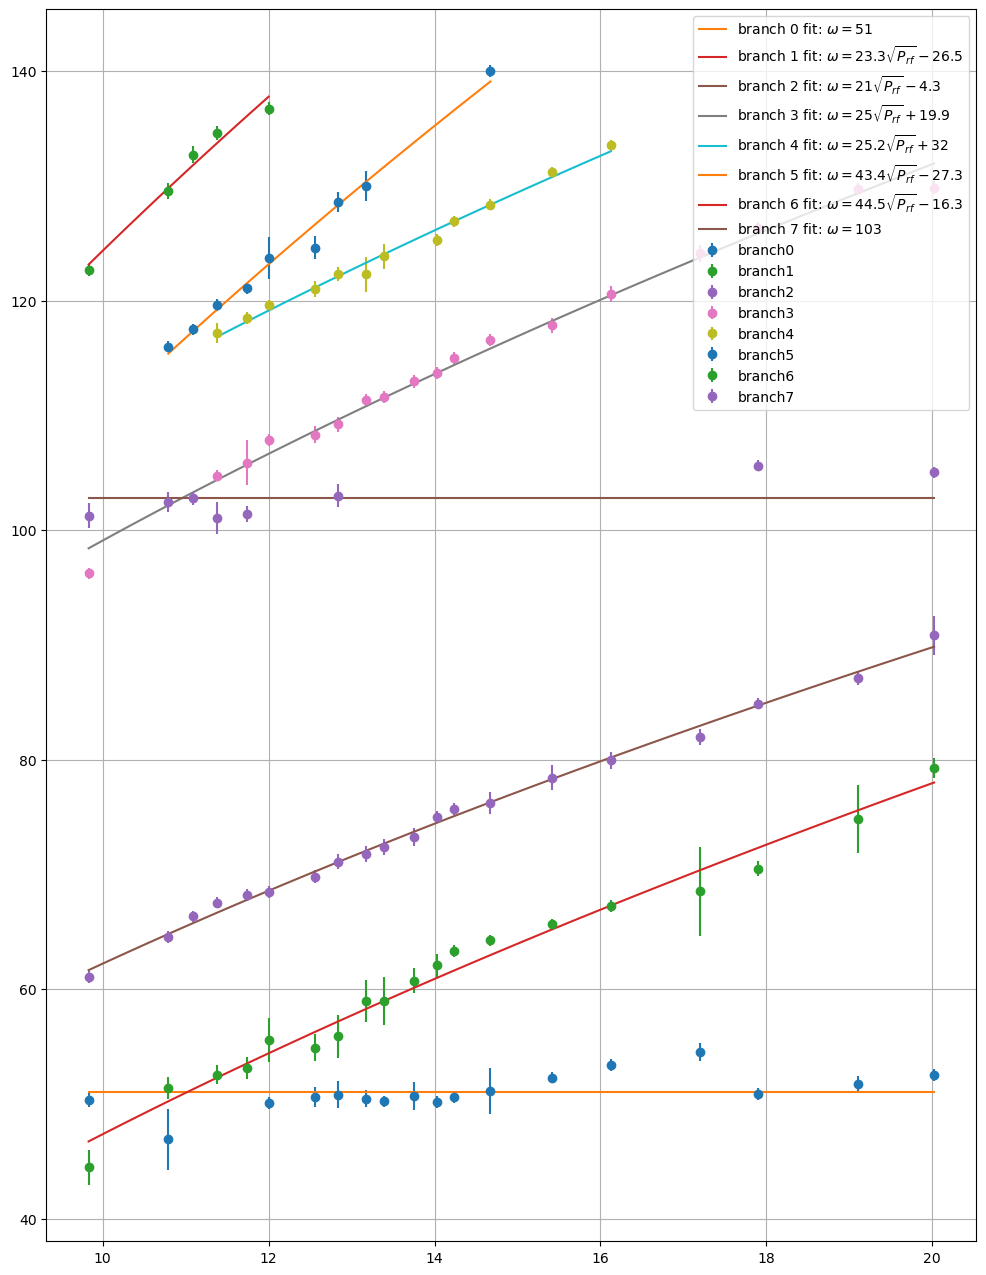

In [9]:
plt.figure(figsize=(12, 16))
for i, family in enumerate(families_lost):
    x = [row[0] for row in family]
    y = [row[1] for row in family]
    yerr = [row[2] for row in family]

    x_fit = np.linspace(min(x), max(x), 100)

    plt.errorbar(x, y, yerr=yerr, linestyle='', fmt='-o', label=f"branch{i}")

    # Plot only the selected fit
    if select_fit[i] == 'sqrt':
        y_fit = sqrt_fit(x_fit, *popt_lost_sqrt[i])
        # sqrt fit: y = a \sqrt{x} + b
        a, b = popt_lost_sqrt[i]
        label_fit = rf"branch {i} fit: $\omega = {a:.3g}\sqrt{{P_{{rf}}}} {b:+.3g}$"
        plt.plot(x_fit, y_fit, label=label_fit)
    elif select_fit[i] == 'const':
        y_fit = constant_fit(x_fit, *popt_lost_const[i])
        # const fit: y = a
        a = popt_lost_const[i][0]
        label_fit = rf"branch {i} fit: $\omega = {a:.3g}$"
        plt.plot(x_fit, y_fit, label=label_fit)
    else:
        raise ValueError(f"Unknown fit selection: {select_fit[i]} for branch {i}")

plt.legend()
plt.grid()
plt.show()


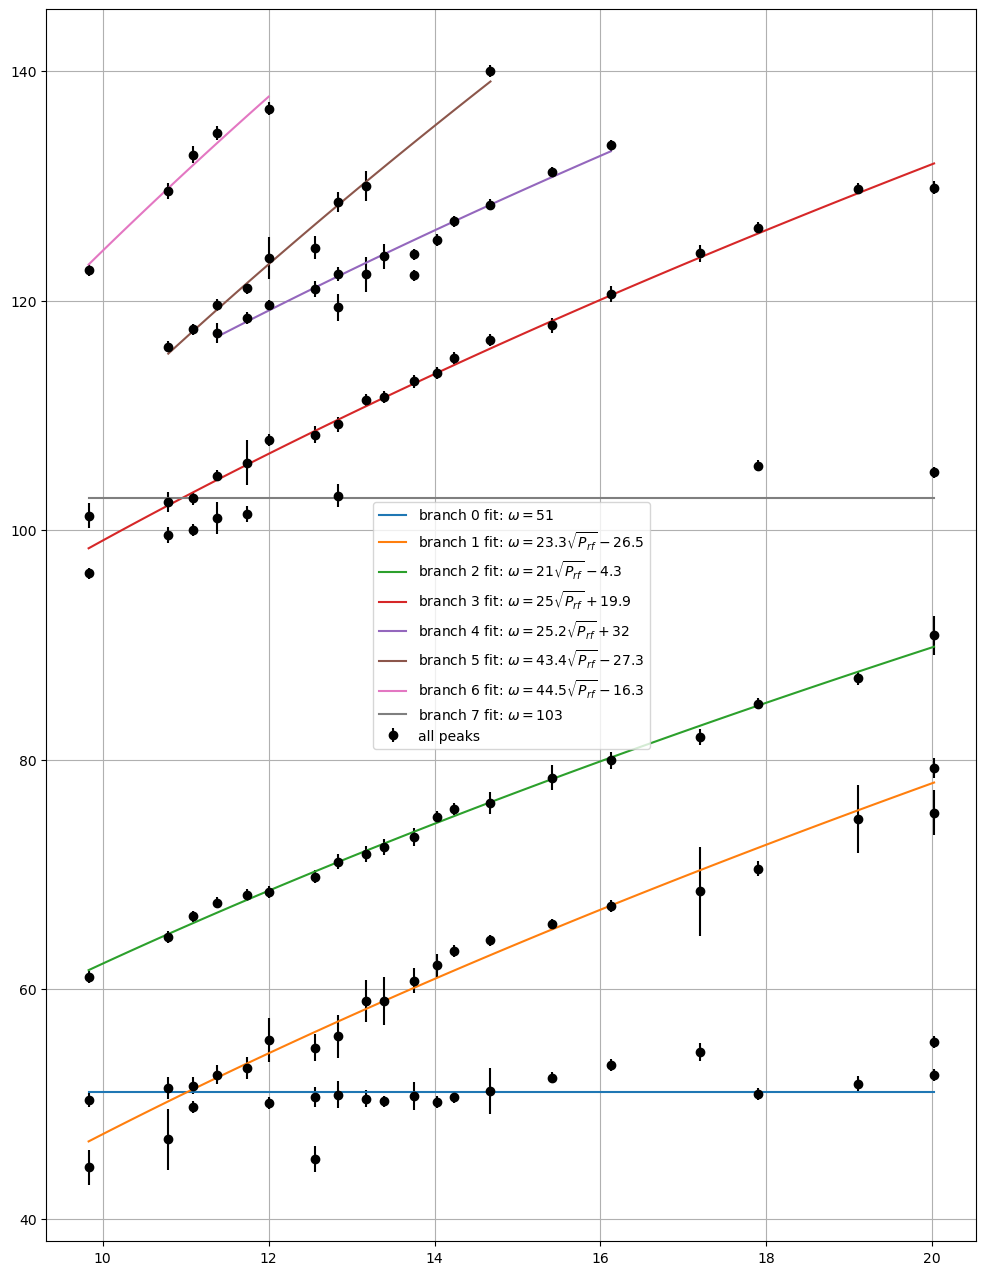

In [10]:
plt.figure(figsize=(12, 16))

# Plot all points in all_peaks_lost as scatter/errorbar
# all_peaks_lost is a list of dicts like:
# [{'RF_set_dBm': -0.5, 'act_RF_mW': X, 'peaks': [{...}, ...]}, ...]
x_all = []
y_all = []
yerr_all = []

for entry in all_peaks_lost:
    x_val = entry['act_RF_mW']
    for peak in entry['peaks']:
        x_all.append(x_val)
        y_all.append(peak['mu'])
        yerr_all.append(peak['sigma'])

plt.errorbar(x_all, y_all, yerr=yerr_all, linestyle='', fmt='o', color='black', label="all peaks")

# Now plot fits for each family as before
for i, family in enumerate(families_lost):
    x = [row[0] for row in family]
    x_fit = np.linspace(min(x), max(x), 100)

    # Plot only the selected fit
    if select_fit[i] == 'sqrt':
        y_fit = sqrt_fit(x_fit, *popt_lost_sqrt[i])
        # sqrt fit: y = a \sqrt{x} + b
        a, b = popt_lost_sqrt[i]
        label_fit = rf"branch {i} fit: $\omega = {a:.3g}\sqrt{{P_{{rf}}}} {b:+.3g}$"
        plt.plot(x_fit, y_fit, label=label_fit)
    elif select_fit[i] == 'const':
        y_fit = constant_fit(x_fit, *popt_lost_const[i])
        # const fit: y = a
        a = popt_lost_const[i][0]
        label_fit = rf"branch {i} fit: $\omega = {a:.3g}$"
        plt.plot(x_fit, y_fit, label=label_fit)
    else:
        raise ValueError(f"Unknown fit selection: {select_fit[i]} for branch {i}")

plt.legend()
plt.grid()
plt.show()


Joint fit model1 params: a, c0, c[1..6] (with c7=2*c0)
  a  = 22.978232409436444
  c0 = 51.278310905576525 => c7 = 102.55662181115305
  c  = {1: -25.07500439211394, 2: -11.538273731039764, 3: 27.69850809396786, 4: 39.96493678717014, 5: -36.118510633418325, 6: -21.22042128338357}
Joint fit model2 params: a, b, c0, c[1..6] (with c7=2*c0)
  a  = 20.59578709972511
  b  = 2.73147212169702
  c0 = 51.278310905576525 => c7 = 102.55662181115305
  c  = {1: -8.142499764978716, 2: 5.39641907486125, 3: 44.62655473755344, 4: 56.83675254233489, 5: -2.304323111600166, 6: 12.780312494682713}
Joint fit model3 params: c0, a1, a2, b (only these 4 free, c7=2*c0)
  c0 = 50.82547996437875 => c7 = 101.6509599287575
  a1 = 18.05156887588187 , a2 = 20.950602233204105 , b = 1.2565358758365246


C:\Users\lluoz\AppData\Local\Temp\ipykernel_14688\2102595891.py:204: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.errorbar(x0, y0, yerr=yerr0, linestyle='', fmt='-o', label='branch0')
C:\Users\lluoz\AppData\Local\Temp\ipykernel_14688\2102595891.py:216: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.errorbar(x7, y7, yerr=yerr7, linestyle='', fmt='-o', label='branch7')
C:\Users\lluoz\AppData\Local\Temp\ipykernel_14688\2102595891.py:228: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.errorbar(x, y, yerr=yerr, linestyle='', fmt='-o', label=f"branch{b1}")


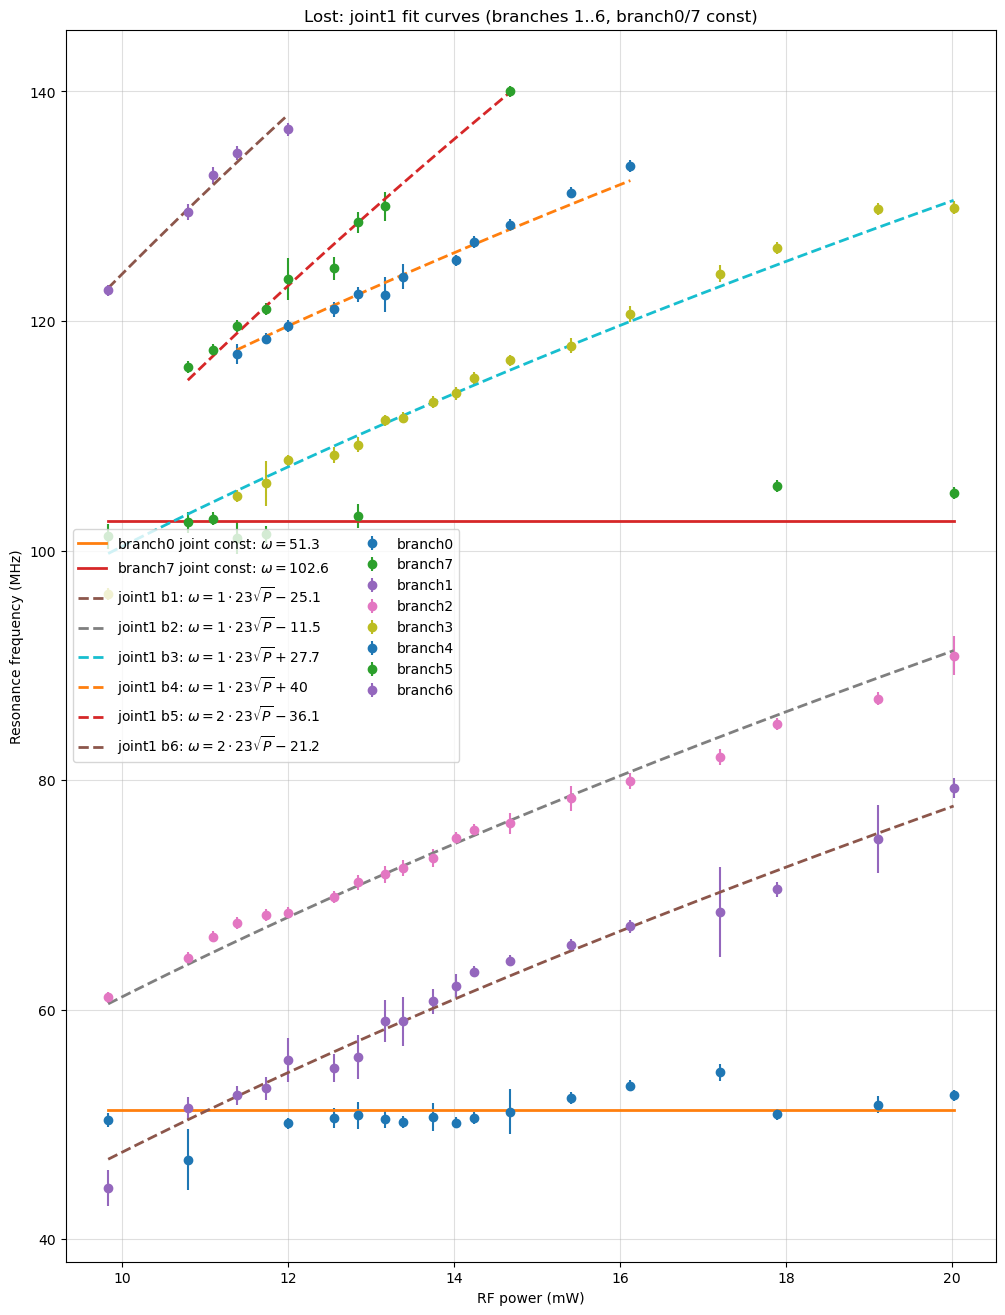

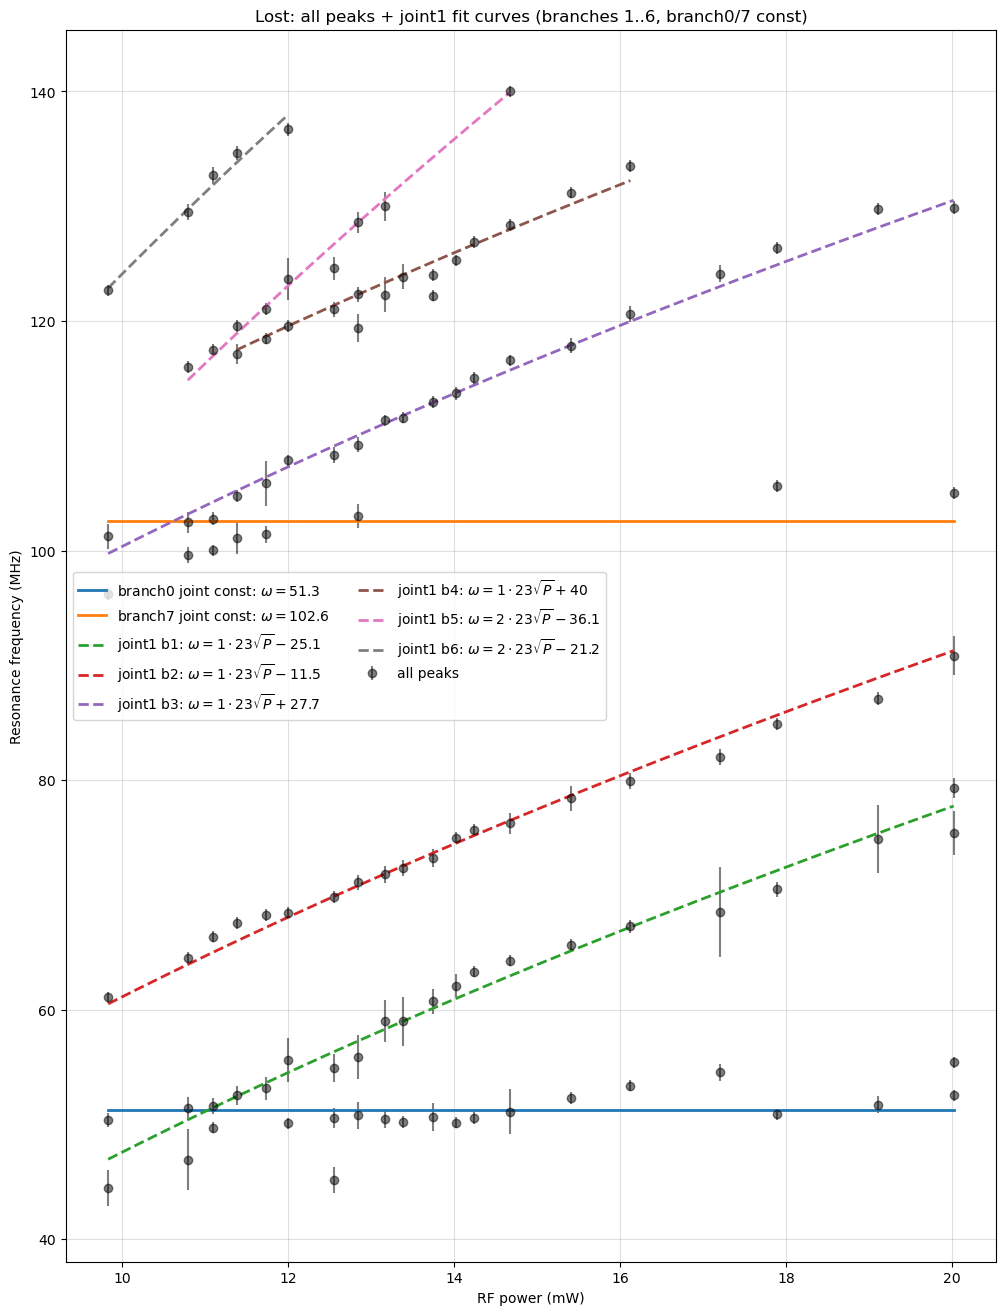

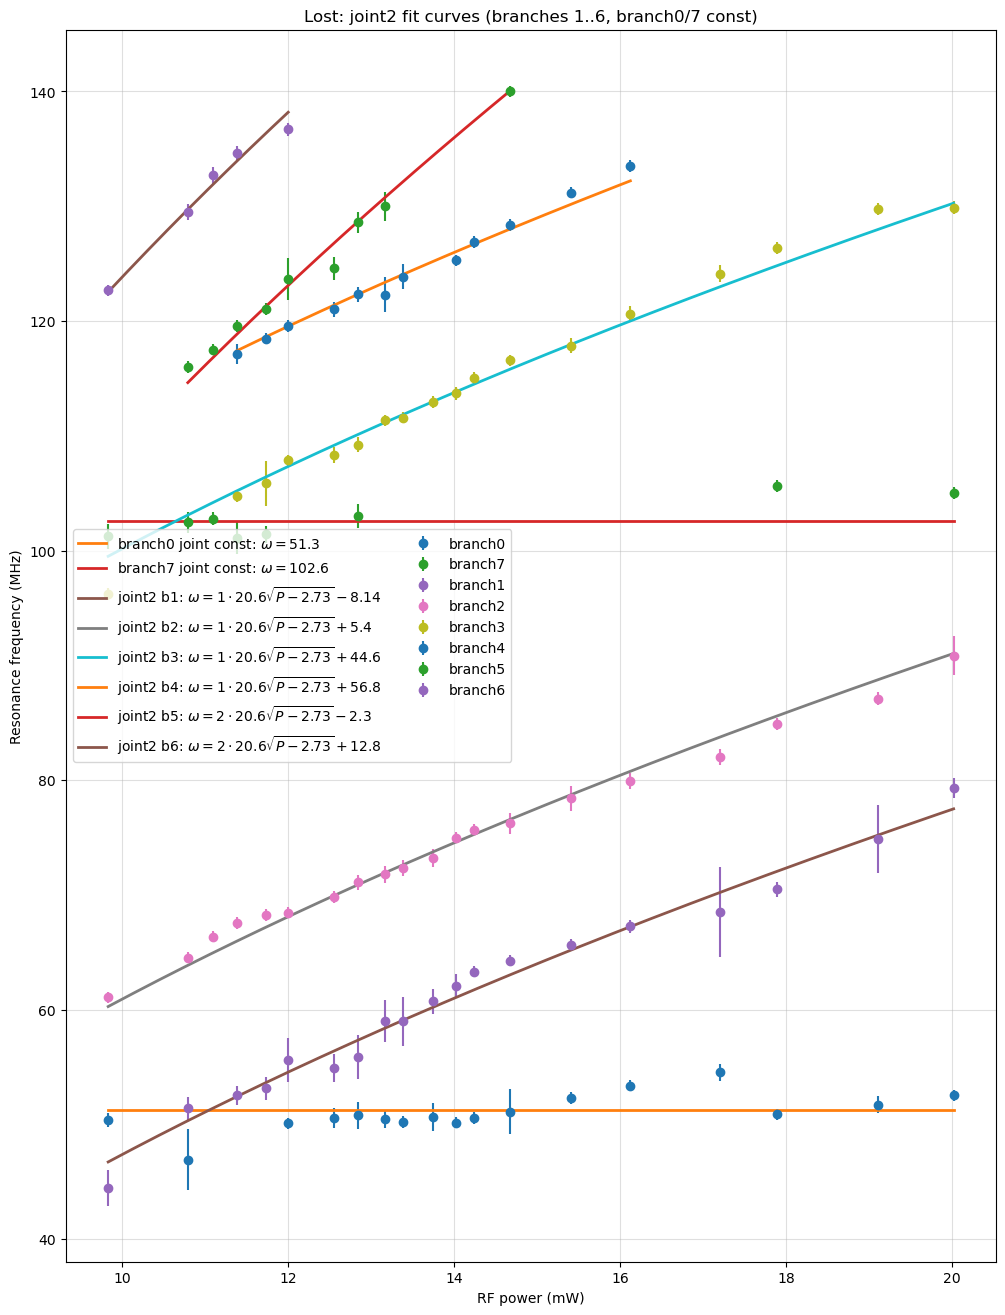

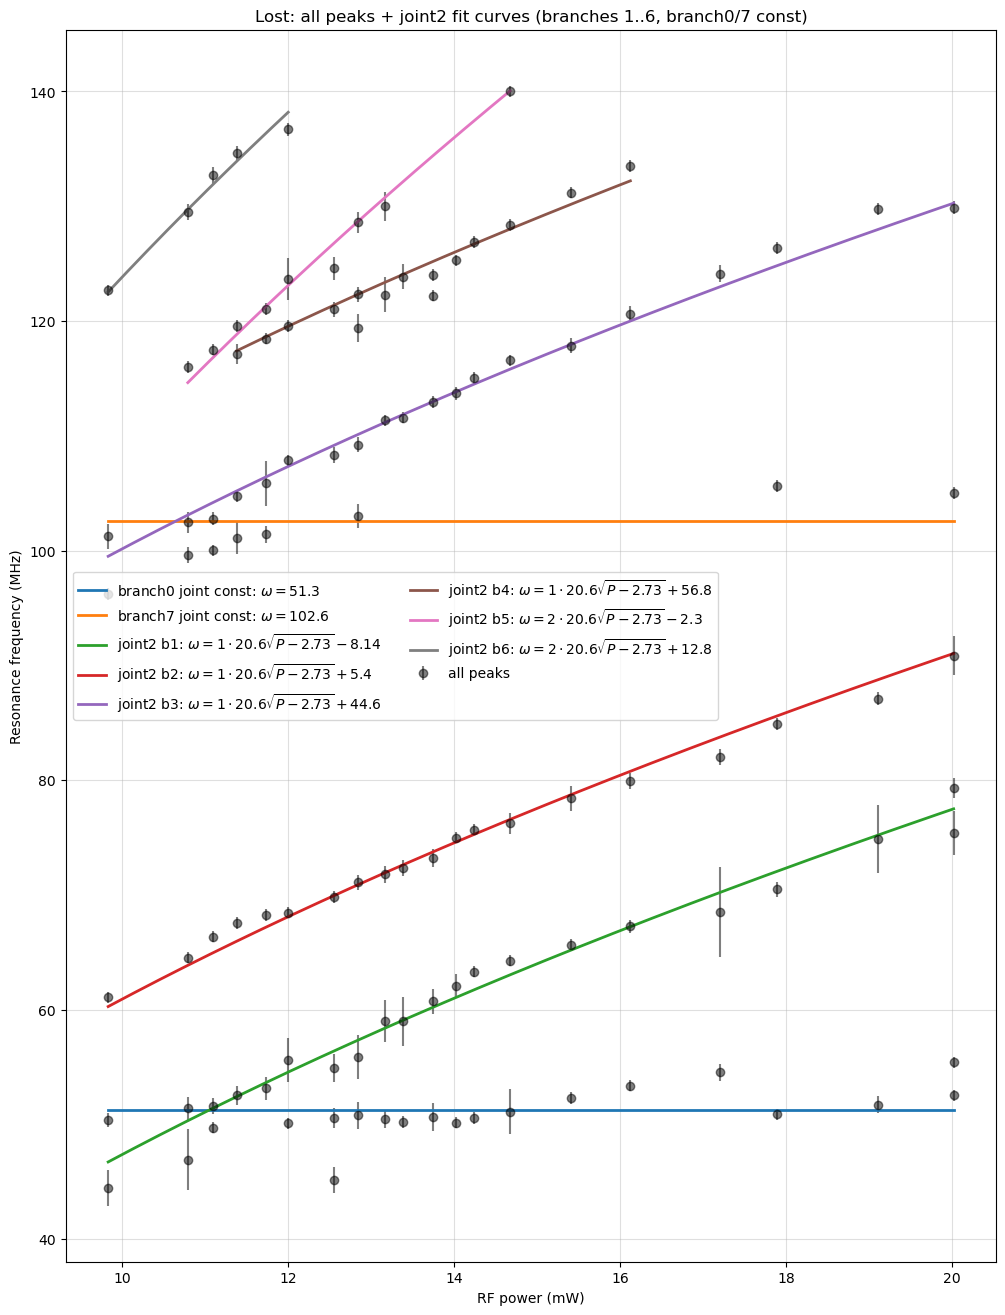

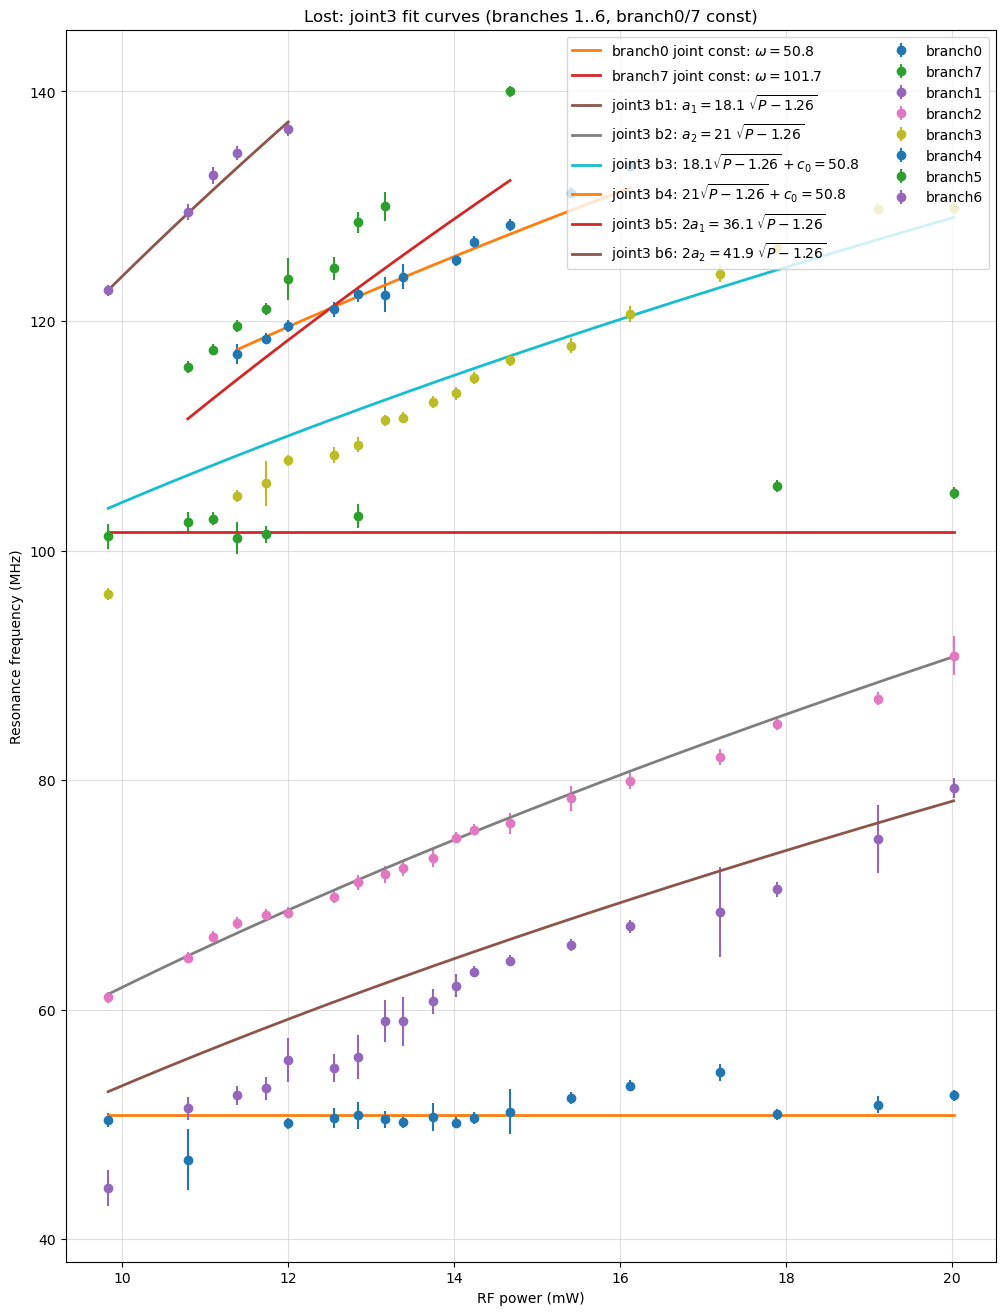

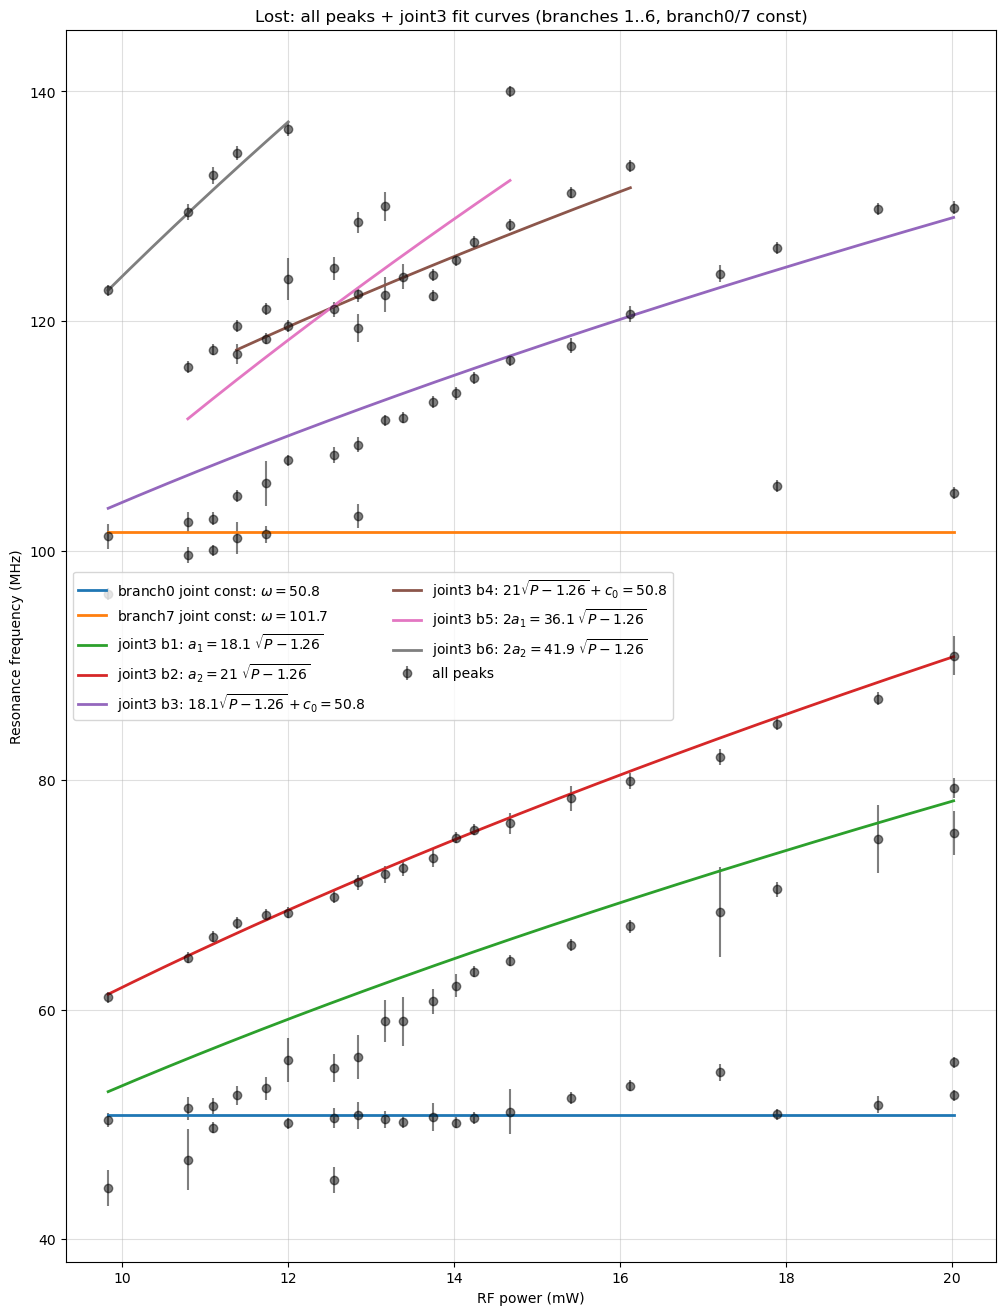

In [11]:
# --- NEW: joint fit for branches 1..6 with fixed k(branch) ---
# Model 1: y = k[branch] * a * sqrt(x) + c[branch]
# Model 2: y = k[branch] * a * sqrt(x - b) + c[branch]
# where k = 1 for branch 1-4, k = 2 for branch 5-6. (branch numbering here is 1-based)

from scipy.optimize import curve_fit

# choose branches for JOINT FIT
# - branch1..6: sqrt models
# - branch0 and branch7: CONST in the joint fit, with constraint c7 = 2*c0
JOINT_BRANCHES = [1, 2, 3, 4, 5, 6]
CONST_BRANCHES = [0, 7]

# collect data (x, y, branch_id) from families_lost
x_all, y_all, bid_all = [], [], []

# branch0/7 (const) points
for b0 in CONST_BRANCHES:
    if len(families_lost) > b0:
        for row in families_lost[b0]:
            x_all.append(float(row[0]))
            y_all.append(float(row[1]))
            bid_all.append(int(b0))

# branch1..6 (sqrt) points
for b1 in JOINT_BRANCHES:
    if len(families_lost) > b1:
        for row in families_lost[b1]:
            x_all.append(float(row[0]))
            y_all.append(float(row[1]))
            bid_all.append(int(b1))

x_all = np.asarray(x_all, dtype=float)
y_all = np.asarray(y_all, dtype=float)
bid_all = np.asarray(bid_all, dtype=int)

# fixed k(branch) for sqrt branches
def k_branch(b1):
    return 1.0 if b1 <= 4 else 2.0

# helper: map sqrt-branch id -> c index
_b_to_idx = {b: j for j, b in enumerate(JOINT_BRANCHES)}

# Model 1 params: [a, c0, c1..c6]
def joint_model_sqrt(X, a, c0, *c):
    x, b = X
    c_arr = np.asarray(c, dtype=float)  # ordered by JOINT_BRANCHES
    out = np.empty_like(x, dtype=float)
    for j, bj in enumerate(b):
        bj = int(bj)
        if bj == 0:
            out[j] = float(c0)
        elif bj == 7:
            out[j] = 2.0 * float(c0)
        else:
            out[j] = k_branch(bj) * float(a) * np.sqrt(float(x[j])) + c_arr[_b_to_idx[bj]]
    return out

# Model 2 params: [a, b, c0, c1..c6]
def joint_model_sqrt_shift(X, a, b_shift, c0, *c):
    x, b = X
    c_arr = np.asarray(c, dtype=float)
    out = np.empty_like(x, dtype=float)
    for j, bj in enumerate(b):
        bj = int(bj)
        if bj == 0:
            out[j] = float(c0)
        elif bj == 7:
            out[j] = 2.0 * float(c0)
        else:
            xx = float(x[j]) - float(b_shift)
            out[j] = k_branch(bj) * float(a) * np.sqrt(xx) + c_arr[_b_to_idx[bj]]
    return out

# Model 3: only c0, a1, a2, b free. branch0=c0, branch7=2*c0; branch1=a1*sqrt(x-b), branch2=a2*sqrt(x-b);
# branch3=a1*sqrt(x-b)+c0, branch4=a2*sqrt(x-b)+c0; branch5=2*a1*sqrt(x-b), branch6=2*a2*sqrt(x-b)
def joint_model_3(X, c0, a1, a2, b):
    x, bid = X
    out = np.empty_like(x, dtype=float)
    for j in range(len(x)):
        bj = int(bid[j])
        xx = float(x[j]) - float(b)
        sqrt_xx = np.sqrt(np.maximum(xx, 1e-12))
        if bj == 0:
            out[j] = float(c0)
        elif bj == 1:
            out[j] = float(a1) * sqrt_xx
        elif bj == 2:
            out[j] = float(a2) * sqrt_xx
        elif bj == 3:
            out[j] = float(a1) * sqrt_xx + float(c0)
        elif bj == 4:
            out[j] = float(a2) * sqrt_xx + float(c0)
        elif bj == 5:
            out[j] = 2.0 * float(a1) * sqrt_xx
        elif bj == 6:
            out[j] = 2.0 * float(a2) * sqrt_xx
        elif bj == 7:
            out[j] = 2.0 * float(c0)
        else:
            out[j] = np.nan
    return out

# initial guesses
p0_a = 20.0
# c0 from branch0 median if available, else global median
p0_c0 = float(np.median([yy for yy, bb in zip(y_all, bid_all) if int(bb) == 0])) if np.any(bid_all == 0) else float(np.median(y_all))
# per-branch c for 1..6
p0_c = [float(np.median(y_all[bid_all == b])) for b in JOINT_BRANCHES]

# --- Fit model 1 ---
# params: [a, c0, c1..c6]
p0_1 = [p0_a, p0_c0] + p0_c
bounds_1 = ([0.0, -np.inf] + [-np.inf] * len(JOINT_BRANCHES), [np.inf] * (2 + len(JOINT_BRANCHES)))

popt_1, pcov_1 = curve_fit(
    joint_model_sqrt,
    (x_all, bid_all),
    y_all,
    p0=p0_1,
    bounds=bounds_1,
    maxfev=200000,
)

# --- Fit model 2 ---
# params: [a, b, c0, c1..c6]
# b must be < min(x) to keep x-b positive for sqrt branches; allow a>=0.
min_x = float(np.min(x_all))
p0_b = 0.0
p0_2 = [p0_a, p0_b, p0_c0] + p0_c
bounds_2 = ([0.0, -np.inf, -np.inf] + [-np.inf] * len(JOINT_BRANCHES), [np.inf, min_x - 1e-6, np.inf] + [np.inf] * len(JOINT_BRANCHES))

popt_2, pcov_2 = curve_fit(
    joint_model_sqrt_shift,
    (x_all, bid_all),
    y_all,
    p0=p0_2,
    bounds=bounds_2,
    maxfev=200000,
)

# --- Fit model 3 ---
# params: [c0, a1, a2, b]; only these 4 free for all branches 0..7
p0_a1 = float(np.median(y_all[bid_all==1] / np.sqrt(np.maximum(x_all[bid_all==1], 1e-6)))) if np.any(bid_all == 1) else 20.0
p0_a2 = float(np.median(y_all[bid_all==2] / np.sqrt(np.maximum(x_all[bid_all==2], 1e-6)))) if np.any(bid_all == 2) else 20.0
p0_3 = [p0_c0, p0_a1, p0_a2, 0.0]
bounds_3 = ([-np.inf, 0.0, 0.0, -np.inf], [np.inf, np.inf, np.inf, min_x - 1e-6])

popt_3, pcov_3 = curve_fit(
    joint_model_3,
    (x_all, bid_all),
    y_all,
    p0=p0_3,
    bounds=bounds_3,
    maxfev=200000,
)

print('Joint fit model1 params: a, c0, c[1..6] (with c7=2*c0)')
print('  a  =', popt_1[0])
print('  c0 =', popt_1[1], '=> c7 =', 2.0 * popt_1[1])
print('  c  =', {b: popt_1[2 + j] for j, b in enumerate(JOINT_BRANCHES)})

print('Joint fit model2 params: a, b, c0, c[1..6] (with c7=2*c0)')
print('  a  =', popt_2[0])
print('  b  =', popt_2[1])
print('  c0 =', popt_2[2], '=> c7 =', 2.0 * popt_2[2])
print('  c  =', {b: popt_2[3 + j] for j, b in enumerate(JOINT_BRANCHES)})

print('Joint fit model3 params: c0, a1, a2, b (only these 4 free, c7=2*c0)')
print('  c0 =', popt_3[0], '=> c7 =', 2.0 * popt_3[0])
print('  a1 =', popt_3[1], ', a2 =', popt_3[2], ', b =', popt_3[3])

def _plot_joint_only_model(model_name, include_all_peaks=False):
    """Make one plot for ONE joint model (model1 or model2)."""
    plt.figure(figsize=(12, 16))

    if include_all_peaks:
        x_allp, y_allp, yerr_allp = [], [], []
        for entry in all_peaks_lost:
            x_val = entry['act_RF_mW']
            for peak in entry['peaks']:
                x_allp.append(x_val)
                y_allp.append(peak['mu'])
                yerr_allp.append(peak['sigma'])
        plt.errorbar(x_allp, y_allp, yerr=yerr_allp, linestyle='', fmt='o', color='black', alpha=0.5, label='all peaks')

    # branch0/7: CONST in JOINT FIT, with c7 = 2*c0
    # Legend for branch0/7 should show 1 decimal.
    if model_name == 'model1':
        c0 = float(popt_1[1])
    elif model_name == 'model2':
        c0 = float(popt_2[2])
    else:
        c0 = float(popt_3[0])

    # branch0
    if len(families_lost) > 0:
        fam0 = families_lost[0]
        x0 = [row[0] for row in fam0]
        y0 = [row[1] for row in fam0]
        yerr0 = [row[2] for row in fam0]
        x0_fit = np.linspace(min(x0), max(x0), 200)
        if not include_all_peaks:
            plt.errorbar(x0, y0, yerr=yerr0, linestyle='', fmt='-o', label='branch0')
        plt.plot(x0_fit, np.full_like(x0_fit, c0), lw=2, label=rf"branch0 joint const: $\omega={c0:.1f}$")

    # branch7
    if len(families_lost) > 7:
        fam7 = families_lost[7]
        x7 = [row[0] for row in fam7]
        y7 = [row[1] for row in fam7]
        yerr7 = [row[2] for row in fam7]
        x7_fit = np.linspace(min(x7), max(x7), 200)
        c7 = 2.0 * c0
        if not include_all_peaks:
            plt.errorbar(x7, y7, yerr=yerr7, linestyle='', fmt='-o', label='branch7')
        plt.plot(x7_fit, np.full_like(x7_fit, c7), lw=2, label=rf"branch7 joint const: $\omega={c7:.1f}$")

    for b1 in JOINT_BRANCHES:
        i = b1
        family = families_lost[i]
        x = [row[0] for row in family]
        y = [row[1] for row in family]
        yerr = [row[2] for row in family]
        x_fit = np.linspace(min(x), max(x), 200)

        if not include_all_peaks:
            plt.errorbar(x, y, yerr=yerr, linestyle='', fmt='-o', label=f"branch{b1}")

        if model_name == 'model1':
            # popt_1 = [a, c0, c1..c6]
            a1 = float(popt_1[0])
            c_b = float(popt_1[2 + JOINT_BRANCHES.index(b1)])
            y_fit = k_branch(b1) * a1 * np.sqrt(x_fit) + c_b
            lbl = rf"joint1 b{b1}: $\omega={k_branch(b1):.0f}\cdot{a1:.3g}\sqrt{{P}}{c_b:+.3g}$"
            plt.plot(x_fit, y_fit, '--', lw=2, label=lbl)
        elif model_name == 'model2':
            # popt_2 = [a, b, c0, c1..c6]
            a2 = float(popt_2[0])
            b2 = float(popt_2[1])
            c_b2 = float(popt_2[3 + JOINT_BRANCHES.index(b1)])
            y_fit2 = k_branch(b1) * a2 * np.sqrt(x_fit - b2) + c_b2
            # Avoid "P--0.571" when b is negative
            b_sym = '-' if b2 >= 0 else '+'
            b_abs = abs(b2)
            lbl = rf"joint2 b{b1}: $\omega={k_branch(b1):.0f}\cdot{a2:.3g}\sqrt{{P{b_sym}{b_abs:.3g}}}{c_b2:+.3g}$"
            plt.plot(x_fit, y_fit2, '-', lw=2, label=lbl)
        elif model_name == 'model3':
            # popt_3 = [c0, a1, a2, b]; show a1, a2, b, c0 in legend
            a1_3, a2_3, b3 = float(popt_3[1]), float(popt_3[2]), float(popt_3[3])
            b_sym = '-' if b3 >= 0 else '+'
            b_abs = abs(b3)
            xfb = np.maximum(x_fit - b3, 1e-12)
            sqrt_xfb = np.sqrt(xfb)
            if b1 == 1:
                y_fit3 = a1_3 * sqrt_xfb
                lbl = rf"joint3 b1: $a_1={a1_3:.3g}\;\sqrt{{P{b_sym}{b_abs:.3g}}}$"
            elif b1 == 2:
                y_fit3 = a2_3 * sqrt_xfb
                lbl = rf"joint3 b2: $a_2={a2_3:.3g}\;\sqrt{{P{b_sym}{b_abs:.3g}}}$"
            elif b1 == 3:
                y_fit3 = a1_3 * sqrt_xfb + c0
                lbl = rf"joint3 b3: ${a1_3:.3g}\sqrt{{P{b_sym}{b_abs:.3g}}}+c_0={c0:.1f}$"
            elif b1 == 4:
                y_fit3 = a2_3 * sqrt_xfb + c0
                lbl = rf"joint3 b4: ${a2_3:.3g}\sqrt{{P{b_sym}{b_abs:.3g}}}+c_0={c0:.1f}$"
            elif b1 == 5:
                y_fit3 = 2.0 * a1_3 * sqrt_xfb
                lbl = rf"joint3 b5: $2a_1={2*a1_3:.3g}\;\sqrt{{P{b_sym}{b_abs:.3g}}}$"
            elif b1 == 6:
                y_fit3 = 2.0 * a2_3 * sqrt_xfb
                lbl = rf"joint3 b6: $2a_2={2*a2_3:.3g}\;\sqrt{{P{b_sym}{b_abs:.3g}}}$"
            else:
                y_fit3 = np.nan; lbl = ''
            plt.plot(x_fit, y_fit3, '-', lw=2, label=lbl)
        else:
            raise ValueError(model_name)

    plt.legend(ncol=2)
    plt.grid(True, alpha=0.4)
    plt.xlabel('RF power (mW)')
    plt.ylabel('Resonance frequency (MHz)')
    title_suffix = 'all peaks + ' if include_all_peaks else ''
    title_model = 'joint1' if model_name == 'model1' else ('joint2' if model_name == 'model2' else 'joint3')
    plt.title(f"Lost: {title_suffix}{title_model} fit curves (branches 1..6, branch0/7 const)")
    plt.show()

# Two plot groups (each fit -> two plots)
# Group 1: model1
_plot_joint_only_model('model1', include_all_peaks=False)
_plot_joint_only_model('model1', include_all_peaks=True)

# Group 2: model2
_plot_joint_only_model('model2', include_all_peaks=False)
_plot_joint_only_model('model2', include_all_peaks=True)

# Group 3: model3 (only c0, a1, a2, b free; branch0=c0, b7=2*c0; b1=a1*sqrt(P-b), b2=a2*sqrt(P-b); b3=a1*sqrt+c0, b4=a2*sqrt+c0; b5=2a1*sqrt, b6=2a2*sqrt)
_plot_joint_only_model('model3', include_all_peaks=False)
_plot_joint_only_model('model3', include_all_peaks=True)

# Export data


In [12]:
import pandas as pd

# 1. all_peaks_lost: flatten to (act_RF_mW, RF_set_dBm, peak_idx, amp, mu, sigma)
rows_peaks = []
for entry in all_peaks_lost:
    for idx, peak in enumerate(entry['peaks']):
        rows_peaks.append({
            'act_RF_mW': entry['act_RF_mW'],
            'RF_set_dBm': entry['RF_set_dBm'],
            'peak_idx': idx,
            'amp': peak['amp'],
            'mu': peak['mu'],
            'sigma': peak['sigma'],
        })
df_all_peaks_lost = pd.DataFrame(rows_peaks)
df_all_peaks_lost.to_csv('outputs/all_peaks_lost.csv', index=False)
print('Exported: outputs/all_peaks_lost.csv  shape:', df_all_peaks_lost.shape)

# 2. families_lost: flatten to (family_id, act_RF_mW, mu, sigma)
rows_families = []
for fam_id, family in enumerate(families_lost):
    for row in family:
        rows_families.append({
            'family_id': fam_id,
            'act_RF_mW': row[0],
            'mu': row[1],
            'sigma': row[2],
        })
df_families_lost = pd.DataFrame(rows_families)
df_families_lost.to_csv('outputs/families_lost.csv', index=False)
print('Exported: outputs/families_lost.csv  shape:', df_families_lost.shape)

Exported: outputs/all_peaks_lost.csv  shape: (118, 6)
Exported: outputs/families_lost.csv  shape: (108, 4)
